# Phase 3: Triton Hardware-Accelerated Fused Kernel
This notebook contains the complete GPU implementation of the fused Matrix Multiplication + Softplus activation kernel. We will compile this using Triton on an NVIDIA T4 GPU, audit the correctness against PyTorch, profile the throughput, and calculate the overall execution efficiency relative to the T4's physical hardware limits.

### Cell 1: Verify Hardware Environment
Ensure we are running on a GPU-enabled Google Colab runtime (preferably an NVIDIA T4).

In [7]:
!nvidia-smi

Mon May 18 12:23:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P0             29W /   70W |     693MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Cell 2: Install Triton & Dependencies
Google Colab runtimes have PyTorch pre-installed. We will install the exact `triton` compiler.

In [8]:
!pip install -q triton

### Cell 3: Fused Matmul + Softplus Triton Kernel
Define the custom hardware kernel. The Softplus function is fused directly into the SRAM tile store stage, saving massive memory bandwidth overhead by avoiding round-trips to High-Bandwidth Memory (HBM).

In [9]:
import torch
import triton
import triton.language as tl

@triton.jit
def fused_physics_alpha_kernel(
    X_ptr, W_ptr, B_ptr, Out_ptr,
    M, N, K,
    stride_xm, stride_xk,
    stride_wn, stride_wk,
    stride_om, stride_on,
    BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr, BLOCK_K: tl.constexpr
):
    # Determine grid coordinates
    pid_m = tl.program_id(axis=0)
    pid_n = tl.program_id(axis=1)

    # Compute SRAM block offsets
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)

    # Set up pointers
    x_ptrs = X_ptr + (offs_m[:, None] * stride_xm + offs_k[None, :] * stride_xk)
    w_ptrs = W_ptr + (offs_k[:, None] * stride_wk + offs_n[None, :] * stride_wn)

    # Accumulate in fast shared registers (SRAM)
    accumulator = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, K, BLOCK_K):
        x_block = tl.load(x_ptrs)
        w_block = tl.load(w_ptrs)
        accumulator += tl.dot(x_block, w_block)
        x_ptrs += BLOCK_K * stride_xk
        w_ptrs += BLOCK_K * stride_wk

    # Add bias
    b_ptrs = B_ptr + offs_n[None, :]
    bias = tl.load(b_ptrs)
    accumulator = accumulator + bias

    # Fused Activation: Softplus [ ln(1 + exp(x)) ]
    accumulator = tl.maximum(0.0, accumulator) + tl.log(1.0 + tl.exp(-tl.abs(accumulator)))

    # Write back block to HBM
    out_ptrs = Out_ptr + (offs_m[:, None] * stride_om + offs_n[None, :] * stride_on)
    mask = (offs_m[:, None] < M) & (offs_n[None, :] < N)
    tl.store(out_ptrs, accumulator, mask=mask)

def run_fused_alpha_layer(x, w, b, block_m=64, block_n=64, block_k=32):
    M, K = x.shape
    K, N = w.shape

    assert x.is_contiguous()
    assert w.is_contiguous()
    assert b.is_contiguous()

    out = torch.empty((M, N), device=x.device, dtype=x.dtype)

    grid = lambda meta: (
        triton.cdiv(M, meta['BLOCK_M']),
        triton.cdiv(N, meta['BLOCK_N']),
    )

    fused_physics_alpha_kernel[grid](
        x, w, b, out,
        M, N, K,
        x.stride(0), x.stride(1),
        w.stride(1), w.stride(0),
        out.stride(0), out.stride(1),
        BLOCK_M=block_m, BLOCK_N=block_n, BLOCK_K=block_k
    )
    return out

### Cell 4: Correctness Check (Verify Output Matching)
Assert that the Triton implementation produces exact numerical results compared to standard PyTorch within typical floating-point precision bounds (`1e-5`).

In [10]:
device = 'cuda'
M, N, K = 512, 512, 512
x = torch.randn((M, K), device=device, dtype=torch.float32)
w = torch.randn((K, N), device=device, dtype=torch.float32)
b = torch.randn((N,), device=device, dtype=torch.float32)

out_triton = run_fused_alpha_layer(x, w, b)
out_torch = torch.nn.functional.softplus(torch.matmul(x, w) + b)

max_diff = torch.max(torch.abs(out_triton - out_torch)).item()
print(f"Correctness Verification:")
print(f"  Max absolute difference: {max_diff:.8f}")

if max_diff < 1e-4:
    print("\n*** CORRECTNESS CHECK PASSED! ***\n")
else:
    print("\n!!! CORRECTNESS CHECK FAILED !!!")
    print("Stop here: Kernel bug detected.")
    raise ValueError("Triton output mismatch!")

Correctness Verification:
  Max absolute difference: 0.00000095

*** CORRECTNESS CHECK PASSED! ***



### Cell 5: Profiling Across Matrix Dimensions
Run Triton's testing suite to compare latency profiles against the PyTorch reference implementation across varying dimension scales.

matmul-performance:
        M       N       K  Triton Fused Layer (GB/s)  PyTorch Native (GB/s)
0   128.0   128.0   128.0                 123.303863             128.376105
1   256.0   256.0   256.0                1115.506385             910.222190
2   512.0   512.0   512.0                3943.868549            3792.318128
3  1024.0  1024.0  1024.0                4540.057853            4748.044696
4  2048.0  2048.0  2048.0                3250.492802            4127.141393


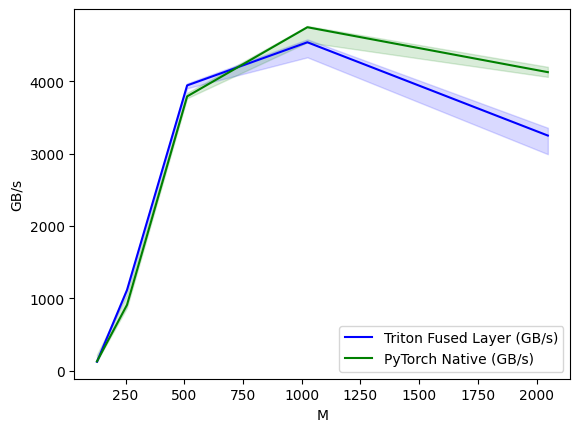

In [11]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['M', 'N', 'K'],
        x_vals=[128, 256, 512, 1024, 2048],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton Fused Layer', 'PyTorch Native'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel='GB/s',
        plot_name='matmul-performance',
        args={}
    )
)
def benchmark(M, N, K, provider):
    x = torch.randn((M, K), device=device, dtype=torch.float32)
    w = torch.randn((K, N), device=device, dtype=torch.float32)
    b = torch.randn((N,), device=device, dtype=torch.float32)

    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.nn.functional.softplus(torch.matmul(x, w) + b), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: run_fused_alpha_layer(x, w, b), quantiles=quantiles)

    gbps = lambda ms: 2 * M * N * K * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=False)

### Cell 6: Hardware Execution Efficiency (TFLOPS)
The theoretical single-precision (FP32) ceiling of the NVIDIA T4 GPU is **8.1 TFLOPS**. We will measure exact execution time to evaluate what percentage of the physical accelerator silicon is utilized.

In [13]:
print("T4 Hardware Peak Comparison (FP32 Matmul):")
print(f"{'Dim (M=N=K)':<15}{'Latency (ms)':<15}{'Measured TFLOPS':<20}{'Accelerator Utilization (%)'}")
print("-" * 75)

dimensions = [256, 512, 1024, 2048]
for dim in dimensions:
    x = torch.randn((dim, dim), device=device, dtype=torch.float32)
    w = torch.randn((dim, dim), device=device, dtype=torch.float32)
    b = torch.randn((dim,), device=device, dtype=torch.float32)

    # Standard Triton execution with default tile sizes
    ms = triton.testing.do_bench(lambda: run_fused_alpha_layer(x, w, b, block_m=64, block_n=64, block_k=32))

    # FLOP count: 2 * M * N * K operations
    flops = 2 * (dim ** 3)
    measured_tflops = (flops / (ms * 1e-3)) / 1e12

    # Peak T4 FP32 TFLOPS = 8.1
    utilization = (measured_tflops / 8.1) * 100

    print(f"{dim:<15}{ms:<15.4f}{measured_tflops:<20.4f}{utilization:.2f}%")

T4 Hardware Peak Comparison (FP32 Matmul):
Dim (M=N=K)    Latency (ms)   Measured TFLOPS     Accelerator Utilization (%)
---------------------------------------------------------------------------
256            0.0570         0.5884              7.26%
512            0.1838         1.4601              18.03%
1024           0.5942         3.6139              44.62%
2048           5.4278         3.1652              39.08%
